# Volatility Forecasting — Consolidated Notebook
### Classical baselines vs ML (XGBoost) vs deep learning (LSTM) for one-day-ahead equity volatility
**BSc (Hons) Data Science & AI, IIT Guwahati — Self-guided Project**

This is the **single-notebook consolidation** of the modular `volforecast/` package that lives next
to it. Every module appears below as one code cell, preceded by a detailed introduction; the code
is byte-for-byte the package source (only the intra-package `from .module import …` lines are
removed, since everything shares one namespace here). Results are therefore identical to the
modular version.

**One practical difference:** the package's `pipeline.py` runs the five heavy pipelines (three
GARCH variants, XGBoost, LSTM) in parallel worker *processes* (~1 min end-to-end). That trick is
unavailable inside a notebook — Windows starts workers by re-importing `__main__`, and functions
defined in notebook cells cannot be pickled by reference — so this notebook runs them **serially**
(~2–3 min end-to-end). Same numbers, slightly longer wait.

**Design invariants that hold everywhere below** (worth internalizing before reading any code):
1. **No look-ahead, ever.** The forecast for day *t* uses information up to day *t−1* only.
2. **One split for all models.** `test_start_index` defines the walk-forward test window once;
   every model — classical or learned — is scored on exactly the same days.
3. **True volatility is latent.** Models are scored against the squared-return proxy `r_t²` with
   the noise-robust **QLIKE** loss, and differences are stress-tested with the
   **Diebold–Mariano** test.

## Module 1 — `config`: run parameters & the walk-forward split
The single source of truth for the whole study. Everything an experimenter might vary lives in
one dict:

- **`ticker` / `start` / `end`** — the asset and sample. S&P 500 from 2008 deliberately includes
  the GFC, the 2018 volmageddon, COVID-2020 and the 2022 bear market: a hard, regime-rich sample.
- **`test_frac = 0.30`** — the last 30% of days (~5 years) is the out-of-sample test window.
- **`roll_window`, `ewma_lambda`** — parameters of the simple baselines (21 trading days ≈ 1 month;
  λ = 0.94 is the classic RiskMetrics daily decay).
- **`garch_refit_every = 22`** — GARCH-family parameters are re-estimated roughly monthly; between
  refits the variance recursion is rolled forward daily with observed returns (fast *and* valid).
- **`EPS`** — numerical floor so no division by or log of zero anywhere downstream.

`test_start_index(r, cfg)` is defined here — not in the evaluation module — because it is the one
number every other module must agree on. If any model used a different split, the leaderboard
would be comparing apples to oranges.

In [2]:
EPS = 1e-12  # numerical floor so we never divide by / log zero

CFG = {
    "ticker":       "^GSPC",     # S&P 500. Try "^NSEI" (Nifty 50), "BTC-USD", "GC=F" (gold)
    "start":        "2007-01-01",
    "end":          "2026-07-03",
    "test_frac":    0.30,        # last 30% of the sample is the out-of-sample test window
    "roll_window":  21,          # window for the rolling-std baseline (~1 trading month)
    "ewma_lambda":  0.94,        # RiskMetrics decay
    "garch_refit_every": 22,     # refit GARCH params every N days (roll recursion in between)
    "garch_window": None,        # None = expanding window; or an int for a rolling estimation window
}


def test_start_index(r, cfg):
    # first index of the out-of-sample walk-forward test window
    return int(len(r) * (1 - cfg["test_frac"]))


## Module 2 — `data`: returns loading & a synthetic fallback
Two ways to obtain the daily **log-return** series `r_t = ln(P_t / P_{t−1})` that everything else
consumes:

- **`load_returns`** pulls auto-adjusted daily closes from Yahoo Finance and differences the log
  price. Log returns (rather than simple returns) are the standard object in the volatility
  literature: they aggregate additively across days and are the quantity GARCH models are written
  for. A small guard handles yfinance occasionally returning a one-column DataFrame instead of a
  Series.
- **`synthetic_returns`** simulates a GARCH(1,1) process with realistic persistence
  (α + β = 0.98). It exists so the whole pipeline can be developed and smoke-tested offline —
  and as a sanity check: on data that *is* GARCH, the GARCH baseline should win, and it does.

In [3]:
import numpy as np
import pandas as pd


def load_returns(cfg):
    import yfinance as yf
    px = yf.download(cfg["ticker"], start=cfg["start"], end=cfg["end"],
                     auto_adjust=True, progress=False)
    close = px["Close"].dropna()
    if isinstance(close, pd.DataFrame):     # yfinance sometimes returns a 1-col frame
        close = close.iloc[:, 0]
    r = np.log(close).diff().dropna()
    r.name = "ret"
    return r


def synthetic_returns(n=4000, omega=2e-6, alpha=0.08, beta=0.90, seed=42):
    rng = np.random.default_rng(seed)
    var = np.empty(n); ret = np.empty(n); var[0] = omega / (1 - alpha - beta); ret[0] = 0.0
    for t in range(1, n):
        var[t] = omega + alpha * ret[t-1]**2 + beta * var[t-1]
        ret[t] = rng.normal(0, np.sqrt(var[t]))
    idx = pd.bdate_range("2010-01-01", periods=n)
    return pd.Series(ret, index=idx, name="ret")


## Module 3 — `metrics`: losses & the Diebold–Mariano test
**Implemented and tested — do not change the logic; trust it.** Scoring a volatility forecast is
subtle because the target is never observed; these four choices are the accepted way to do it:

- **RMSE / MAE** are computed on the **volatility scale** (√variance) purely for
  interpretability — a RMSE of 0.009 means "typically ~0.9 vol points off per day".
- **QLIKE** is computed on the **variance scale**: `mean(p/v − ln(p/v) − 1)` where `p` is the
  squared-return proxy and `v` the forecast. It is the headline metric here because it is
  *robust* to proxy noise (Patton 2011): its ranking of models is consistent even though `r²` is
  a very noisy estimate of true variance. It also punishes **under**-prediction of variance more
  than over-prediction — exactly the asymmetry a risk manager wants.
- **`dm_test`** implements Diebold–Mariano with the Harvey–Leybourne–Newbold small-sample
  correction: given two per-day loss series, it tests whether the mean loss difference is
  statistically distinguishable from zero. Negative statistic ⇒ model 1 better. Without this,
  a leaderboard gap of 0.01 QLIKE is just noise-reading.

In [4]:
# Evaluation utilities — implemented and tested, do not change the logic.
import numpy as np
from scipy.stats import t as tdist


def rmse(vol_f, vol_true):
    vol_f, vol_true = np.asarray(vol_f), np.asarray(vol_true)
    return float(np.sqrt(np.mean((vol_f - vol_true) ** 2)))


def mae(vol_f, vol_true):
    return float(np.mean(np.abs(np.asarray(vol_f) - np.asarray(vol_true))))


def qlike_series(var_f, proxy_var):
    v = np.clip(np.asarray(var_f), EPS, None)
    p = np.asarray(proxy_var) + EPS
    return p / v - np.log(p / v) - 1.0        # per-observation QLIKE loss


def qlike(var_f, proxy_var):
    return float(np.mean(qlike_series(var_f, proxy_var)))


# Diebold-Mariano. loss1, loss2 = per-obs loss arrays (from qlike_series or squared error).
# Returns (stat, p_value). Negative stat => model 1 has lower loss (better).
def dm_test(loss1, loss2, h=1):
    d = np.asarray(loss1) - np.asarray(loss2)
    T = len(d); dbar = d.mean()
    gamma0 = np.mean((d - dbar) ** 2)
    s = gamma0
    for k in range(1, h):                      # autocovariances up to h-1 (0 for 1-step)
        s += 2 * np.mean((d[k:] - dbar) * (d[:-k] - dbar))
    stat = dbar / np.sqrt(s / T)
    stat *= np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)   # HLN correction
    p = 2 * tdist.cdf(-abs(stat), df=T - 1)
    return float(stat), float(p)


## Module 4 — `features`: predictors & the learning target
Shared by both learned models (XGBoost and LSTM) so they compete on identical information.

**Features** (all shifted so row *t* contains only data through *t−1*):
- `r_lag1..10`, `r2_lag1..10` — recent returns and squared returns: the raw material of
  volatility clustering, and signed returns let a model discover the leverage effect on its own.
- `rv5`, `rv21` — realized variance over the last week and month. Together with the daily lags
  this spans the short/medium/long horizons of the HAR model of Corsi (2009), the strongest
  simple realized-vol forecaster known.
- `absmean5` — mean absolute return over the last week; a robust (outlier-resistant) vol proxy.

**Target — the key design decision:** regressing raw `r_t²` with squared-error loss fails
(the proxy is so noisy the model collapses toward a constant). Instead the target is the **log**
of the **5-day-forward average** squared return: averaging slashes the proxy noise, and the log
makes the target roughly Gaussian — friendly to both boosted trees and an MSE-trained LSTM.
Because the target for day *t* is only fully observed at *t+4*, every training set below excludes
a `buffer` of the most recent days: the honesty cost of a forward-looking target.

In [5]:
import numpy as np
import pandas as pd


def make_features(r, max_lag=10):
    X = pd.DataFrame(index=r.index)
    for k in range(1, max_lag + 1):
        X[f"r_lag{k}"]  = r.shift(k)
        X[f"r2_lag{k}"] = (r ** 2).shift(k)
    X["rv5"]  = (r ** 2).shift(1).rolling(5).mean()
    X["rv21"] = (r ** 2).shift(1).rolling(21).mean()
    X["absmean5"] = r.abs().shift(1).rolling(5).mean()
    # TODO: add features you can justify — realized skew/kurt, day-of-week, VIX, etc.
    return X


# target: log of a smoothed realized variance (avoids the noisy-proxy blow-up).
# rv_target looks 5 days FORWARD (today + next 4), so it is only known once those returns
# have occurred — a `buffer` of stale days is left out of every training refit to respect that.
def make_target(r):
    rv_target = (r ** 2).rolling(5).mean().shift(-4)
    return np.log(rv_target + EPS)


## Module 5 — `baselines`: naive, rolling, EWMA, and the GARCH family
Strong, honest classical baselines — beating them is genuinely hard, which is the point of the
project. Each function returns a full-length array of one-day-ahead **variance** forecasts.

- **`bl_naive`** — tomorrow's variance = today's squared return. Unbiased but maximally noisy;
  its catastrophic QLIKE (four orders of magnitude worse) is a feature of the loss, not a bug:
  QLIKE explodes when a forecast is near zero and the realization is not.
- **`bl_rolling`** — variance of the previous 21 returns: the "one-month historical vol" quoted
  on every trading desk.
- **`bl_ewma`** — RiskMetrics: `v_t = λ·v_{t−1} + (1−λ)·r_{t−1}²`. One parameter, no estimation,
  embarrassingly hard to beat.
- **`bl_garch_family`** — one engine for three models, selected by arguments:
  - **GARCH(1,1)** (`o=0`): `σ²_t = ω + α·r²_{t−1} + β·σ²_{t−1}`.
  - **GJR-GARCH** (`o=1`): adds `γ·r²_{t−1}·1[r_{t−1}<0]` — negative returns raise tomorrow's
    variance more than positive ones (the leverage effect), as a threshold term.
  - **EGARCH** (`vol="EGARCH"`): models **log** variance with a signed standardized-residual
    term — leverage again, with positivity guaranteed by construction.

  Estimation scheme: parameters are re-fit by maximum likelihood (via the `arch` package) every
  22 days on an expanding window; on the days in between, the recursion is rolled forward one day
  at a time with observed returns. The hand-rolled recursions were **verified line-by-line against
  `arch`'s own internal `garch_recursion` / `egarch_recursion` source**, so the daily updates are
  mathematically identical to what the fitted parameters imply. Returns are scaled ×100 before
  fitting (MLE numerical stability) and forecasts scaled back.

In [6]:
# Classical baselines. Each returns a full-length array of one-day-ahead variance
# forecasts where the forecast for day t uses information up to day t-1 only.
import numpy as np


def bl_naive(r):
    # tomorrow's variance = today's squared return
    return (r.shift(1) ** 2).values


def bl_rolling(r, k):
    # variance of the previous k returns
    return r.shift(1).rolling(k).var().values


def bl_ewma(r, lam):
    v = np.empty(len(r)); v[:] = np.nan
    v[0] = r.iloc[:22].var()
    rv = r.values
    for t in range(1, len(r)):
        v[t] = lam * v[t-1] + (1 - lam) * rv[t-1] ** 2   # uses r_{t-1}: no look-ahead
    return v


# GARCH-family baseline: refit params every `garch_refit_every` days, roll the variance
# recursion forward daily with the observed returns in between (fast AND valid).
# One function drives plain GARCH(1,1), GJR-GARCH (o=1, leverage via a threshold term) and
# EGARCH (o=1, leverage via the standardized-residual term) — recursions taken directly from
# the `arch` package's own garch_recursion / egarch_recursion so they match the fitted params.
def bl_garch_family(r, cfg, vol="GARCH", o=0, dist="normal"):
    from arch import arch_model
    rr = r.values * 100.0                       # scale up for numerical stability
    T = len(r); fc = np.full(T, np.nan)
    om = al = be = ga = None                     # params hoisted to floats at each refit
    sig2 = None; log_sig2 = None; z = None
    c = np.sqrt(2 / np.pi)                       # E|z| for a standard normal z (EGARCH)
    start = test_start_index(r, cfg)
    for t in range(start, T):
        if (t - start) % cfg["garch_refit_every"] == 0:
            lo = 0 if cfg["garch_window"] is None else max(0, t - cfg["garch_window"])
            res = arch_model(rr[lo:t], mean="Zero", vol=vol, p=1, o=o, q=1,
                             dist=dist).fit(disp="off")
            p = res.params
            om, al, be = p["omega"], p["alpha[1]"], p["beta[1]"]
            ga = p["gamma[1]"] if o == 1 else 0.0
            last_sigma = res.conditional_volatility[-1]
            sig2 = last_sigma ** 2
            log_sig2 = np.log(sig2)
            z = rr[t-1] / last_sigma                     # standardized residual, for EGARCH
        elif vol == "EGARCH":
            log_sig2 = om + be * log_sig2 + al * (abs(z) - c) + ga * z
            sig2 = np.exp(log_sig2)
        elif o == 1:                                       # GJR-GARCH (threshold ARCH)
            lev = ga * rr[t-1] ** 2 if rr[t-1] < 0 else 0.0
            sig2 = om + al * rr[t-1] ** 2 + lev + be * sig2
        else:                                               # plain GARCH(1,1)
            sig2 = om + al * rr[t-1] ** 2 + be * sig2
        fc[t] = sig2 / (100.0 ** 2)             # back to original scale
        if vol == "EGARCH":
            z = rr[t] / np.sqrt(sig2)            # today's standardized residual, feeds tomorrow
    return fc


## Module 6 — `ml_xgboost`: walk-forward gradient boosting
Gradient-boosted trees on the engineered features, predicting the log smoothed-RV target, run as
a **true walk-forward**:

- Every `refit_every` (= 22) days, the model is re-trained **from scratch** on all rows whose
  5-day-forward target is fully realized before the refit date (`buffer=5` — see the features
  module for why). This mirrors the GARCH refit cadence exactly, so the comparison is fair.
- The same fitted model then serves every day until the next refit, and each day's feature row
  uses past data only — so predicting the whole 22-day block in one vectorized call is *identical*
  to per-day prediction, just faster (the feature matrix is hoisted to a numpy array once).
- Hyperparameters (400 trees, depth 3, lr 0.03, row/column subsampling 0.8) are a deliberately
  conservative, low-variance configuration: with only ~3–4k training rows of noisy financial
  data, small trees and heavy shrinkage are the sane default.
- **Warm-starting** each refit from the previous booster was considered and rejected: it either
  grows the ensemble each refit or changes tree composition, so predictions drift — and a
  from-scratch fit costs only a couple of seconds. Correctness beats a micro-optimization.
- Predictions are exponentiated back from log-variance to variance.

In [7]:
# Walk-forward XGBoost on engineered features, predicting log smoothed realized variance.
import numpy as np


def bl_xgboost(r, cfg, refit_every=None, buffer=5):
    import xgboost as xgb
    refit_every = cfg["garch_refit_every"] if refit_every is None else refit_every

    X = make_features(r)
    y = make_target(r)
    full = X.join(y.rename("y"))

    T = len(r)
    fc = np.full(T, np.nan)
    Xv = X.values                               # hoisted once — no per-day .iloc in the loop
    bad = X.isna().any(axis=1).values
    start = test_start_index(r, cfg)
    model = None
    # NOTE: warm-starting each refit from the previous booster (xgb_model=) was considered
    # and rejected — it either grows the ensemble every refit or changes which trees the
    # model contains, so predictions drift from the reference run; a from-scratch 400-tree
    # depth-3 fit on ~3-4k rows takes only a couple of seconds anyway.
    for t0 in range(start, T, refit_every):
        # only rows whose 5-day-forward target is fully realized before day t0 may be used
        # for training — this is what keeps the periodic refit walk-forward-honest.
        train = full.iloc[:t0 - buffer].dropna()
        Xtr, ytr = train.drop(columns="y"), train["y"]
        model = xgb.XGBRegressor(n_estimators=400, max_depth=3, learning_rate=0.03,
                                 subsample=0.8, colsample_bytree=0.8)
        model.fit(Xtr, ytr)
        # the same model serves every day until the next refit, and each day's features use
        # past data only — so predicting the whole block at once is identical to per-day calls
        t1 = min(t0 + refit_every, T)
        ok = ~bad[t0:t1]
        if ok.any():
            fc[np.arange(t0, t1)[ok]] = np.exp(model.predict(Xv[t0:t1][ok]))
    return fc, model


## Module 7 — `ml_lstm`: sequence model with early stopping
An LSTM reads the last `seq_len=20` days of the (standardized) feature matrix and predicts the
same log smoothed-RV target as XGBoost. Every anti-leakage and anti-overfitting guard is explicit:

- **`make_sequences`** builds `(n_samples, seq_len, n_features)` windows, each labelled with the
  target at its **last** row — a sequence never contains rows after its own label date. It is
  vectorized with `numpy.sliding_window_view`, verified **bit-identical** to the naive per-window
  Python loop it replaced.
- **Split**: the test window matches every other model; a validation slice is carved from the
  **end of the training window** (never from test) for early stopping.
- **Standardization** uses train-only means and standard deviations — fitting a scaler on all
  data is one of the most common silent look-ahead bugs in published ML-finance work.
- **Architecture**: a single LSTM layer of 32 hidden units plus a linear head. Deliberately
  small: ~2,600 training sequences of noisy daily data cannot support a deep stack, and the
  honest question is whether *any* recurrence beats GARCH, not how big a model can be built.
- **Training**: Adam on MSE in log-variance space, mini-batches of 64, up to 200 epochs with
  **early stopping** (patience 15) on validation loss, restoring the best checkpoint before
  predicting. Seeded for reproducibility; predictions exponentiate back to variance.

In [8]:
# LSTM over the last seq_len days of features, predicting log smoothed realized variance.
import numpy as np
import torch
import torch.nn as nn
from numpy.lib.stride_tricks import sliding_window_view
from torch.utils.data import TensorDataset, DataLoader


class VolLSTM(nn.Module):
    def __init__(self, n_features, hidden=32, layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, layers, batch_first=True,
                             dropout=dropout if layers > 1 else 0.0)
        self.head = nn.Linear(hidden, 1)      # predicts log-variance

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


def make_sequences(Xs, y, seq_len):
    # Xs (standardized features), y (target) share a DatetimeIndex.
    # Sequence i covers rows [i, i+seq_len) and is labelled with the target at its LAST row,
    # so it never sees a target date's own future.
    # Vectorized with sliding_window_view (bit-identical to the old per-window Python loop).
    Xv = Xs.values.astype(np.float32)
    yv = y.values.astype(np.float32)
    seqs = np.ascontiguousarray(
        sliding_window_view(Xv, seq_len, axis=0).transpose(0, 2, 1))
    targets = yv[seq_len - 1:]
    idx = Xs.index[seq_len - 1:]
    return seqs, targets, idx


def bl_lstm(r, cfg, seq_len=20, hidden=32, layers=1, dropout=0.0,
            epochs=200, patience=15, lr=1e-3, batch_size=64, val_frac=0.15, seed=42):
    torch.manual_seed(seed)

    X = make_features(r)
    y = make_target(r)                        # same smoothed log-variance target as XGBoost
    data = X.join(y.rename("y")).dropna()
    feat_cols = [c for c in data.columns if c != "y"]

    split = data.index[int(len(data) * (1 - cfg["test_frac"]))]
    train_full = data.loc[:split]
    val_i = int(len(train_full) * (1 - val_frac))       # validation = last slice of TRAIN, not test
    train_end = train_full.index[val_i - 1]
    val_end = train_full.index[-1]

    # standardize using TRAIN-only statistics (never fit on val/test)
    mu = train_full.iloc[:val_i][feat_cols].mean()
    sigma = train_full.iloc[:val_i][feat_cols].std().replace(0, 1.0)
    Xs = (data[feat_cols] - mu) / sigma

    seqs, targets, idx = make_sequences(Xs, data["y"], seq_len)
    train_mask = idx <= train_end
    val_mask = (idx > train_end) & (idx <= val_end)
    test_mask = idx > val_end

    Xtr, ytr = torch.tensor(seqs[train_mask]), torch.tensor(targets[train_mask])
    Xval, yval = torch.tensor(seqs[val_mask]), torch.tensor(targets[val_mask])
    Xte = torch.tensor(seqs[test_mask])
    idx_te = idx[test_mask]

    model = VolLSTM(n_features=len(feat_cols), hidden=hidden, layers=layers, dropout=dropout)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)

    best_val, best_state, bad_epochs = np.inf, None, 0
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            vloss = loss_fn(model(Xval), yval).item()
        if vloss < best_val - 1e-6:
            best_val, bad_epochs = vloss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred_var = np.exp(model(Xte).numpy())

    fc = np.full(len(r), np.nan)
    pos = {ts: i for i, ts in enumerate(r.index)}
    for ts, v in zip(idx_te, pred_var):
        fc[pos[ts]] = v
    print(f"LSTM: early-stopped at epoch {epoch + 1}, best val MSE(log-var) = {best_val:.5f}")
    return fc, model


## Module 8 — `evaluate`: leaderboard & significance
Turns the dict of forecast arrays into the two headline artifacts:

- **`build_leaderboard`** — for each model, over the common test window: mask out days the model
  cannot forecast (warm-up NaNs), compute RMSE and MAE on the volatility scale and QLIKE on the
  variance scale, and sort by QLIKE (the noise-robust criterion — see the metrics module).
- **`dm_vs_best_baseline`** — takes the leaderboard winner and the best *classical baseline*
  other than it, aligns the days where both produce forecasts, and runs the Diebold–Mariano test
  on the per-day QLIKE loss differential. This is the guardrail against over-claiming: a model
  is only "better" if the DM test says the loss gap is unlikely to be luck.

In [9]:
import numpy as np
import pandas as pd


BASELINE_NAMES = ["Naive", "Rolling(21)", "EWMA(0.94)",
                  "GARCH(1,1)", "GJR-GARCH(1,1)", "EGARCH(1,1)"]


def build_leaderboard(forecasts, r, cfg):
    sl = slice(test_start_index(r, cfg), len(r))
    proxy_test = (r.values ** 2)[sl]          # realized-variance proxy = squared return
    vol_true = np.sqrt(proxy_test)

    rows = []
    for name, fc in forecasts.items():
        vp = fc[sl]
        mask = np.isfinite(vp)
        vp_m, px_m, vt_m = vp[mask], proxy_test[mask], vol_true[mask]
        vf = np.sqrt(np.clip(vp_m, EPS, None))
        rows.append({"Model": name, "N": mask.sum(),
                     "RMSE": rmse(vf, vt_m), "MAE": mae(vf, vt_m), "QLIKE": qlike(vp_m, px_m)})
    return pd.DataFrame(rows).set_index("Model").sort_values("QLIKE")


# DM test on QLIKE: best model overall vs the best *baseline* (skipping the best model itself).
def dm_vs_best_baseline(forecasts, leaderboard, r, cfg, baselines=BASELINE_NAMES):
    sl = slice(test_start_index(r, cfg), len(r))
    proxy_test = (r.values ** 2)[sl]

    best = leaderboard.index[0]
    ref = leaderboard.loc[[m for m in baselines if m != best], "QLIKE"].idxmin()
    m = np.isfinite(forecasts[best][sl]) & np.isfinite(forecasts[ref][sl])
    stat, p = dm_test(qlike_series(forecasts[best][sl][m], proxy_test[m]),
                      qlike_series(forecasts[ref][sl][m],  proxy_test[m]))
    return best, ref, stat, p


## Module 9 — `pipeline`: orchestration (serial in this notebook)
Runs the three cheap closed-form baselines inline, then the five heavy pipelines (three GARCH
variants, XGBoost, LSTM) one after another with progress timing.

In the modular package, this module dispatches the five heavy jobs to a
`ProcessPoolExecutor` — they are mutually independent, CPU-bound fits, so processes (not threads:
the GIL) cut wall-clock time to roughly the slowest single job (~1 minute total). **Here they run
serially**: Windows starts worker processes by re-importing `__main__`, and functions defined in
notebook cells cannot be pickled by reference, so process-based parallelism is structurally
unavailable to notebook-defined code. Expect ~2–3 minutes; the numbers are identical either way.

In [10]:
# Orchestration. The package version (volforecast/pipeline.py) runs the five heavy jobs in
# parallel worker processes; notebook-defined functions cannot cross a process boundary on
# Windows (spawn re-imports __main__), so this consolidated notebook runs them serially.
import time


def run_all_forecasts(r, cfg):
    # cheap closed-form baselines: run inline
    forecasts = {
        "Naive":       bl_naive(r),
        "Rolling(21)": bl_rolling(r, cfg["roll_window"]),
        "EWMA(0.94)":  bl_ewma(r, cfg["ewma_lambda"]),
    }
    jobs = {
        "GARCH(1,1)":     lambda: bl_garch_family(r, cfg, vol="GARCH", o=0),
        "GJR-GARCH(1,1)": lambda: bl_garch_family(r, cfg, vol="GARCH", o=1),
        "EGARCH(1,1)":    lambda: bl_garch_family(r, cfg, vol="EGARCH", o=1),
        "XGBoost":        lambda: bl_xgboost(r, cfg)[0],
        "LSTM":           lambda: bl_lstm(r, cfg)[0],
    }
    t0 = time.perf_counter()
    for name, job in jobs.items():
        forecasts[name] = job()
        print(f"  {name:<15s} done  [{time.perf_counter() - t0:5.0f}s]")
    return forecasts


## Run — data, forecasts, leaderboard, significance, plot
The orchestration itself: load the returns, run every model over the common walk-forward test
window, rank by QLIKE, test the winner against the best classical baseline with Diebold–Mariano,
and plot the winning forecast against realized volatility.

In [11]:
USE_SYNTHETIC = False  # set True to develop offline with simulated returns

r = synthetic_returns() if USE_SYNTHETIC else load_returns(CFG)
print(f"{len(r)} daily returns, {r.index.min().date()} → {r.index.max().date()}")


4904 daily returns, 2007-01-04 → 2026-07-02


In [12]:
forecasts = run_all_forecasts(r, CFG)


  GARCH(1,1)      done  [    2s]
  GJR-GARCH(1,1)  done  [    3s]
  EGARCH(1,1)     done  [    5s]
  XGBoost         done  [   29s]
LSTM: early-stopped at epoch 66, best val MSE(log-var) = 0.86147
  LSTM            done  [   46s]


### Forecast volatilities & their persistence
Two diagnostics now that every model's forecasts are in hand:

1. **All forecasts vs realized** — each model's one-day-ahead volatility (√variance) over the test
   window, with realized |r| greyed in behind. All models track the same clusters; what separates
   them is smoothness vs responsiveness at the spikes (COVID-2020 is the acid test). The Naive
   forecast is omitted from the overlay — it is just yesterday's |r|, so it buries the others in
   noise without adding information.
2. **Correlogram** — the ACF of returns vs the ACF of realized |r| over the same window. Returns
   are serially uncorrelated (no free lunch in the mean), while |r| shows slowly decaying,
   strongly significant autocorrelation — volatility clustering. That persistence is the *entire*
   signal every model above exploits, and its slow decay is why smooth, persistent forecasters
   (the GARCH family, EWMA) are so hard to beat.

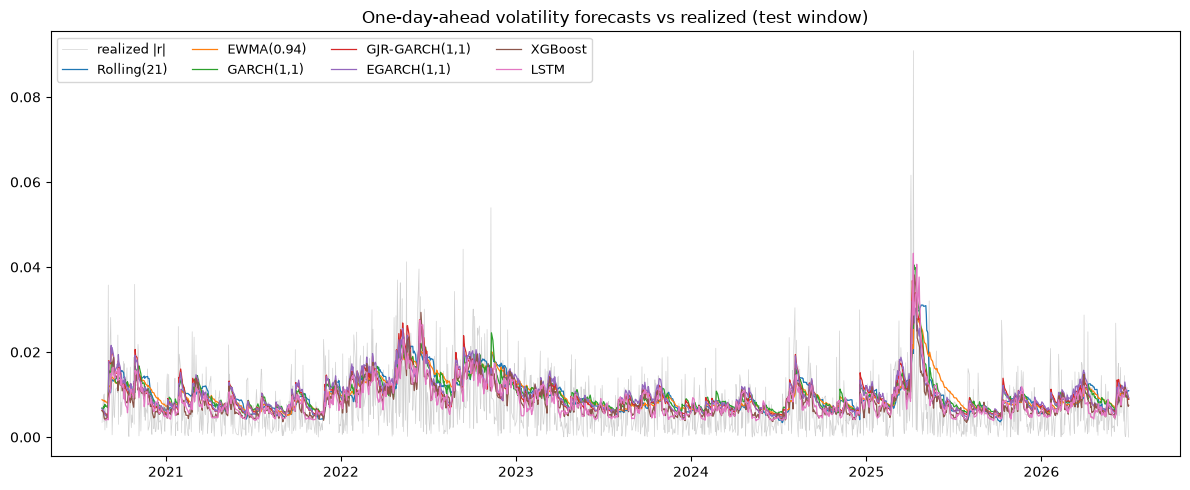

In [13]:
import matplotlib.pyplot as plt

sl = slice(test_start_index(r, CFG), len(r))
idx = r.index[sl]
vol_true = np.abs(r.values[sl])                 # realized |r| = sqrt of the proxy variance

plt.figure(figsize=(12, 5))
plt.plot(idx, vol_true, lw=0.5, alpha=0.35, color="grey", label="realized |r|")
for name, fc in forecasts.items():
    if name == "Naive":
        continue                     # yesterday's |r| — pure noise on top of the grey line
    plt.plot(idx, np.sqrt(np.clip(fc[sl], EPS, None)), lw=0.9, label=name)
plt.title("One-day-ahead volatility forecasts vs realized (test window)")
plt.legend(ncol=4, fontsize=9)
plt.tight_layout(); plt.show()


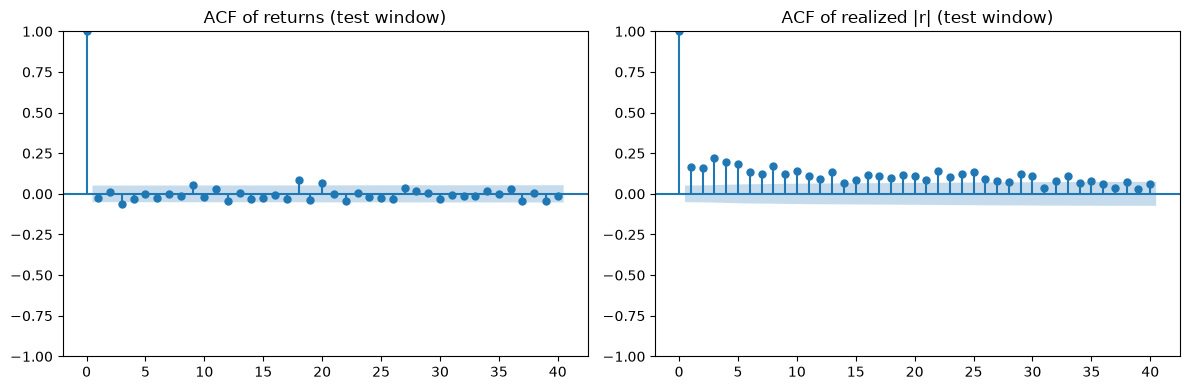

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(r.values[sl], lags=40, ax=ax[0], title="ACF of returns (test window)")
plot_acf(vol_true, lags=40, ax=ax[1], title="ACF of realized |r| (test window)")
plt.tight_layout(); plt.show()


In [15]:
leaderboard = build_leaderboard(forecasts, r, CFG)
display(leaderboard.round(6))

best, ref, stat, p = dm_vs_best_baseline(forecasts, leaderboard, r, CFG)
print(f"DM: {best} vs {ref}  (QLIKE)  stat={stat:.3f}  p={p:.4f}")
print(f"→ {'significant' if p < 0.05 else 'NOT significant'} at 5% "
      f"({best + ' better' if stat < 0 else ref + ' better'})")


,N,RMSE,MAE,QLIKE
Model,,,,
"GJR-GARCH(1,1)",1472,0.007363,0.005564,1.525831
"EGARCH(1,1)",1472,0.007349,0.005594,1.531644
"GARCH(1,1)",1472,0.007563,0.005805,1.550366
EWMA(0.94),1472,0.007527,0.005761,1.578307
LSTM,1463,0.006925,0.005028,1.584743
XGBoost,1472,0.006976,0.005035,1.623564
Rolling(21),1472,0.007660,0.005757,1.647771
Naive,1472,0.009543,0.006755,5167.873129


DM: GJR-GARCH(1,1) vs EGARCH(1,1)  (QLIKE)  stat=-0.554  p=0.5796
→ NOT significant at 5% (GJR-GARCH(1,1) better)


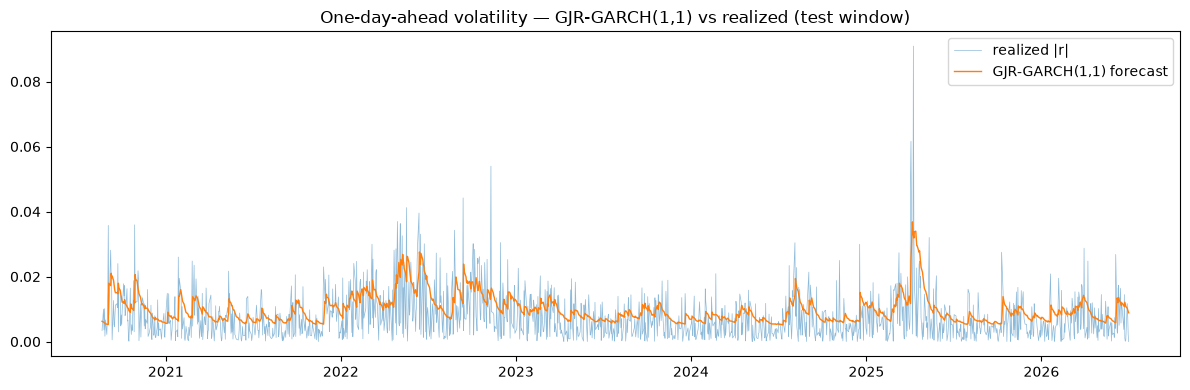

In [16]:
import matplotlib.pyplot as plt

sl = slice(test_start_index(r, CFG), len(r))
vol_true = np.abs(r.values[sl])                 # realized |r| = sqrt of the proxy variance
best_fc = np.sqrt(np.clip(forecasts[best][sl], EPS, None))
idx = r.index[sl]
plt.figure(figsize=(12, 4))
plt.plot(idx, vol_true, lw=0.5, alpha=0.5, label="realized |r|")
plt.plot(idx, best_fc, lw=1.0, label=f"{best} forecast")
plt.title(f"One-day-ahead volatility — {best} vs realized (test window)")
plt.legend(); plt.tight_layout(); plt.show()
